# Olist Brazilian E-Commerce — Data Pipeline Analysis
### End-to-End Data Engineering Project

This notebook connects to our BigQuery data warehouse and performs 
exploratory data analysis on the Olist star schema.

**Pipeline Stack:**
- Ingestion: Meltano → BigQuery
- Transformation: dbt (staging + star schema)
- Data Quality: dbt tests + Great Expectations
- Orchestration: Dagster

**Analysis covers:**
1. Monthly sales trends
2. Top-selling products by revenue
3. Category revenue vs untapped potential
4. Customer segmentation by purchase behaviour
5. Delivery performance (national overview)
6. Delivery performance by state
7. Revenue by state (geographic analysis)
8. Payment method breakdown
9. Review score analysis (customer satisfaction)
10. Full business insights summary

In [17]:
from dotenv import load_dotenv
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
import warnings
warnings.filterwarnings("ignore")

# Load project ID from .env file
load_dotenv()
PROJECT_ID = os.environ.get("GCP_PROJECT_ID")
DATASET = "olist_dbt_olist_dbt"

# Setup BigQuery client
client = bigquery.Client(project=PROJECT_ID)

# Plot styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("✅ Connected to BigQuery successfully!")
print(f"Dataset: {DATASET}")

✅ Connected to BigQuery successfully!
Dataset: olist_dbt_olist_dbt


## 1. Monthly Sales Trends
Analysing total revenue and order volume month by month to identify growth patterns and seasonality in the Olist marketplace.

In [39]:
query_monthly = f"""
SELECT
    FORMAT_DATE('%Y-%m', order_purchase_timestamp) AS month,
    COUNT(DISTINCT order_id) AS total_orders,
    ROUND(SUM(total_order_value), 2) AS total_revenue
FROM `{PROJECT_ID}.{DATASET}.fact_orders`
WHERE order_purchase_timestamp IS NOT NULL
GROUP BY month
ORDER BY month
"""

df_monthly = client.query(query_monthly).to_dataframe()
df_monthly["total_revenue"] = df_monthly["total_revenue"].astype(float).round(2)
print(f"Months of data: {len(df_monthly)}")
df_monthly.head(20)

Months of data: 25


,month,total_orders,total_revenue
0,2016-09,4,354.75
1,2016-10,324,56808.84
2,2016-12,1,19.62
3,2017-01,800,137188.49
4,2017-02,1780,286280.62
5,2017-03,2682,432048.59
6,2017-04,2404,412422.24
7,2017-05,3700,586190.95
8,2017-06,3245,502963.04
9,2017-07,4026,584971.62


In [40]:
query_total = f"""
SELECT
    ROUND(SUM(total_order_value), 2) AS total_revenue,
    COUNT(DISTINCT order_id) AS total_orders,
    COUNT(DISTINCT customer_id) AS total_customers
FROM `{PROJECT_ID}.{DATASET}.fact_orders`
WHERE order_purchase_timestamp IS NOT NULL
"""

df_total = client.query(query_total).to_dataframe()
print(f"Total Revenue:   BRL {df_total['total_revenue'][0]:,.2f}")
print(f"Total Orders:    {df_total['total_orders'][0]:,}")
print(f"Total Customers: {df_total['total_customers'][0]:,}")

Total Revenue:   BRL 15,843,553.24
Total Orders:    99,441
Total Customers: 99,441


### Monthly Revenue and Order Volume Chart

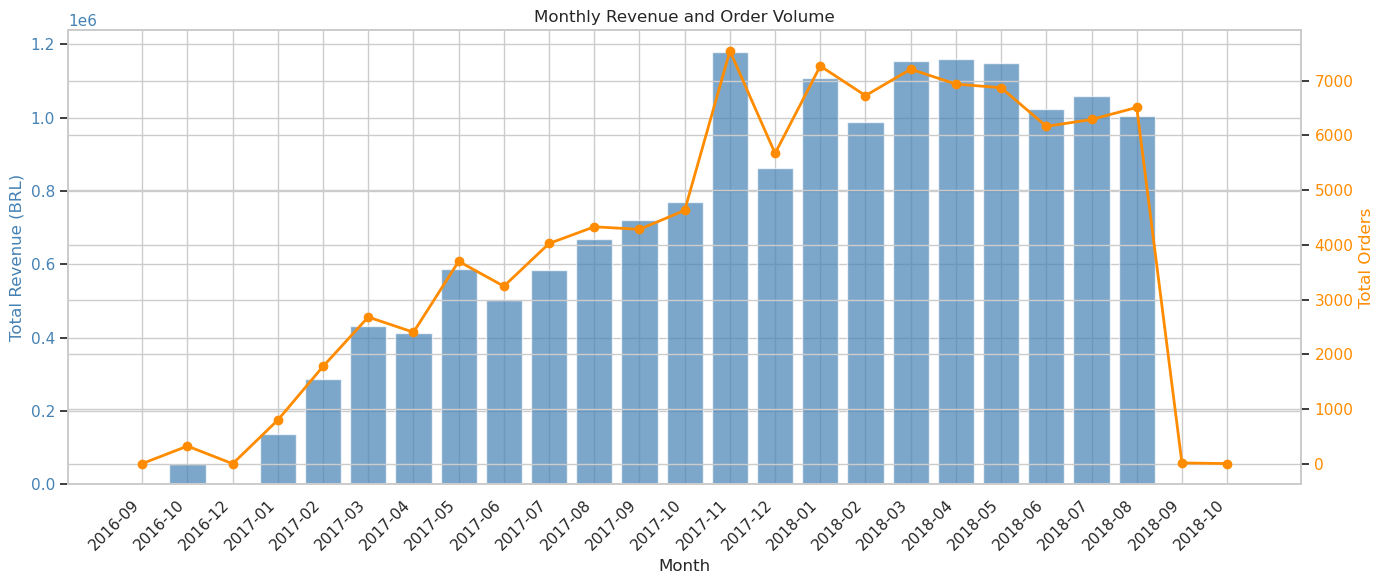

✅ Chart saved


In [20]:
fig, ax1 = plt.subplots(figsize=(14, 6))

color = "steelblue"
ax1.set_xlabel("Month")
ax1.set_ylabel("Total Revenue (BRL)", color=color)
ax1.bar(df_monthly["month"], df_monthly["total_revenue"], color=color, alpha=0.7)
ax1.tick_params(axis="y", labelcolor=color)
plt.xticks(rotation=45, ha="right")

ax2 = ax1.twinx()
color2 = "darkorange"
ax2.set_ylabel("Total Orders", color=color2)
ax2.plot(df_monthly["month"], df_monthly["total_orders"], color=color2, marker="o", linewidth=2)
ax2.tick_params(axis="y", labelcolor=color2)

plt.title("Monthly Revenue and Order Volume")
fig.tight_layout()
plt.savefig("/home/dsai/olist-pipeline/docs/monthly_sales_trends.png", dpi=150)
plt.show()
print("✅ Chart saved")

### 📊 Finding
Revenue and order volume grew steadily from 2016 to late 2017, peaking in November 2017 — likely driven by Black Friday. 
There is a sharp drop in late 2018 which reflects incomplete data for that period rather than an actual decline.

### 💡 Business Implication
Olist should invest heavily in Q4 marketing and logistics capacity to capitalise on the November sales peak. 
Year-on-year growth indicates a healthy, expanding marketplace.

## 2. Top-selling products by revenue
Identifying the top 10 product categories by total revenue to understand 
which categories drive the most business value for Olist.

In [22]:
STAGING = "olist_dbt_olist_staging"

query_products = f"""
SELECT
    p.product_category_name_english AS category,
    COUNT(DISTINCT oi.order_id) AS total_orders,
    ROUND(SUM(oi.price), 2) AS total_revenue,
    ROUND(AVG(oi.price), 2) AS avg_order_value
FROM `{PROJECT_ID}.{STAGING}.stg_order_items` oi
JOIN `{PROJECT_ID}.{DATASET}.dim_product` p
    ON oi.product_id = p.product_id
WHERE p.product_category_name_english IS NOT NULL
GROUP BY category
ORDER BY total_revenue DESC
LIMIT 15
"""

df_products = client.query(query_products).to_dataframe()
df_products["total_revenue"] = df_products["total_revenue"].astype(float).round(2)
df_products["avg_order_value"] = df_products["avg_order_value"].astype(float).round(2)
print("Top 15 product categories by revenue:")
df_products

Top 15 product categories by revenue:


,category,total_orders,total_revenue,avg_order_value
0,health_beauty,8836,1258681.34,130.16
1,watches_gifts,5624,1205005.68,201.14
2,bed_bath_table,9417,1036988.68,93.30
3,sports_leisure,7720,988048.97,114.34
4,computers_accessories,6689,911954.32,116.51
5,furniture_decor,6449,729762.49,87.56
6,cool_stuff,3632,635290.85,167.36
7,housewares,5884,632248.66,90.79
8,auto,3897,592720.11,139.96
9,garden_tools,3518,485256.46,111.63


In [24]:
query_products = f"""
SELECT
    p.product_category_name_english AS category,
    COUNT(DISTINCT oi.order_id) AS total_orders,
    ROUND(SUM(oi.price), 2) AS total_revenue,
    ROUND(AVG(oi.price), 2) AS avg_order_value
FROM `{PROJECT_ID}.{STAGING}.stg_order_items` oi
JOIN `{PROJECT_ID}.{DATASET}.dim_product` p
    ON oi.product_id = p.product_id
WHERE p.product_category_name_english IS NOT NULL
GROUP BY category
ORDER BY total_revenue DESC
LIMIT 15
"""

df_products = client.query(query_products).to_dataframe()
df_products["total_revenue"] = df_products["total_revenue"].astype(float).round(2)
df_products["avg_order_value"] = df_products["avg_order_value"].astype(float).round(2)
print("Top 15 product categories by revenue:")
df_products

Top 15 product categories by revenue:


,category,total_orders,total_revenue,avg_order_value
0,health_beauty,8836,1258681.34,130.16
1,watches_gifts,5624,1205005.68,201.14
2,bed_bath_table,9417,1036988.68,93.30
3,sports_leisure,7720,988048.97,114.34
4,computers_accessories,6689,911954.32,116.51
5,furniture_decor,6449,729762.49,87.56
6,cool_stuff,3632,635290.85,167.36
7,housewares,5884,632248.66,90.79
8,auto,3897,592720.11,139.96
9,garden_tools,3518,485256.46,111.63


### Top 10 Product Categories Chart

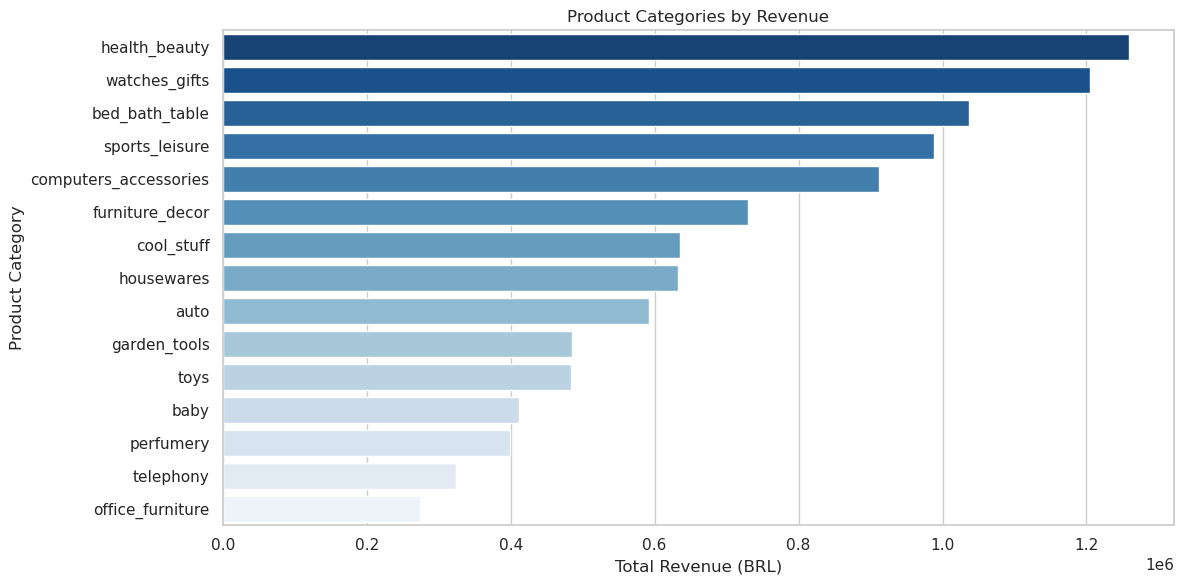

✅ Chart saved


In [16]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df_products,
    x="total_revenue",
    y="category",
    hue="category",
    palette="Blues_r",
    legend=False
)
plt.title("Product Categories by Revenue")
plt.xlabel("Total Revenue (BRL)")
plt.ylabel("Product Category")
plt.tight_layout()
plt.savefig("/home/dsai/olist-pipeline/docs/top_products.png", dpi=150)
plt.show()
print("✅ Chart saved")

## 3. Category revenue vs untapped potential

Beyond identifying the top revenue category, we examine which categories have high average order values but low order volumes. These represent untapped commercial opportunities — premium buyers exist, but the market is underpenetrated.

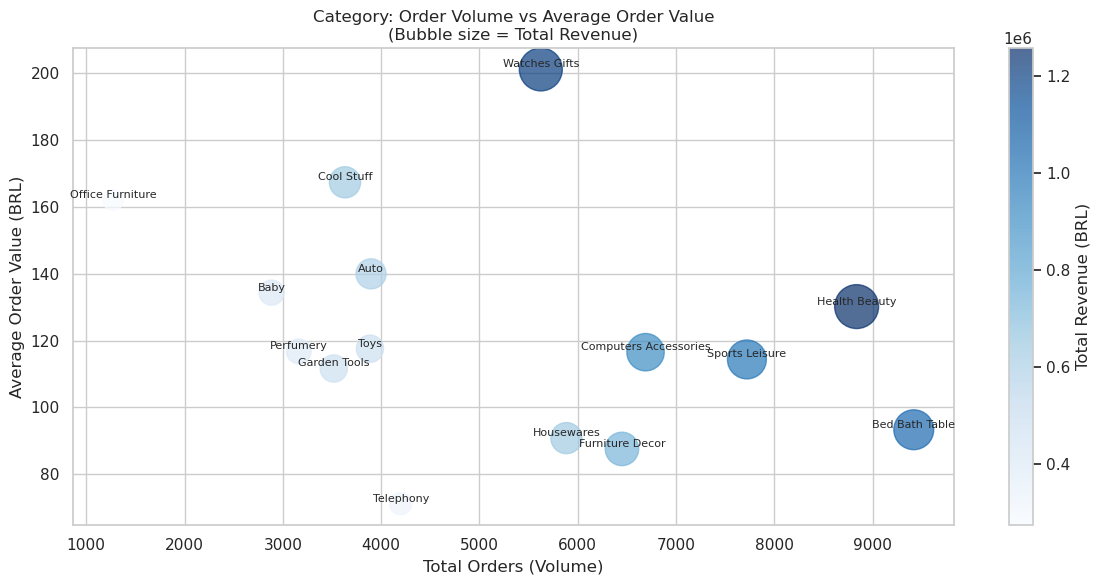


Key Findings — Category Opportunity
Highest revenue:     Health Beauty — BRL 1,258,681.34
Highest AOV:         Watches Gifts — BRL 201.14 avg order value
Highest volume:      Bed Bath Table — 9,417 orders

Low volume, high value (untapped potential):
  Watches Gifts                 BRL    201 avg order value  —  5,624 orders
  Cool Stuff                    BRL    167 avg order value  —  3,632 orders
  Office Furniture              BRL    162 avg order value  —  1,273 orders
  Auto                          BRL    140 avg order value  —  3,897 orders
  Baby                          BRL    134 avg order value  —  2,885 orders
  Health Beauty                 BRL    130 avg order value  —  8,836 orders
  Toys                          BRL    118 avg order value  —  3,886 orders


In [25]:
query_cat = f"""
SELECT
    p.product_category_name_english AS category,
    COUNT(DISTINCT oi.order_id) AS total_orders,
    ROUND(SUM(oi.price), 2) AS total_revenue,
    ROUND(AVG(oi.price), 2) AS avg_order_value
FROM `{PROJECT_ID}.{STAGING}.stg_order_items` oi
JOIN `{PROJECT_ID}.{DATASET}.dim_product` p
    ON oi.product_id = p.product_id
WHERE p.product_category_name_english IS NOT NULL
GROUP BY category
ORDER BY total_revenue DESC
LIMIT 15
"""

df_cat = client.query(query_cat).to_dataframe()
df_cat['total_orders'] = df_cat['total_orders'].astype(float)
df_cat['total_revenue'] = df_cat['total_revenue'].astype(float)
df_cat['avg_order_value'] = df_cat['avg_order_value'].astype(float)

# Normalise bubble size
bubble_size = (df_cat['total_revenue'] / df_cat['total_revenue'].max()) * 1000

fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(
    df_cat['total_orders'],
    df_cat['avg_order_value'],
    s=bubble_size,
    alpha=0.7,
    c=df_cat['total_revenue'],
    cmap='Blues'
)
for _, row in df_cat.iterrows():
    ax.annotate(
        row['category'].replace('_', ' ').title(),
        (row['total_orders'], row['avg_order_value']),
        fontsize=8, ha='center', va='bottom'
    )
ax.set_xlabel('Total Orders (Volume)')
ax.set_ylabel('Average Order Value (BRL)')
ax.set_title('Category: Order Volume vs Average Order Value\n(Bubble size = Total Revenue)')
plt.colorbar(scatter, label='Total Revenue (BRL)')
plt.tight_layout()
plt.savefig('docs/category_opportunity.png', dpi=150, bbox_inches='tight')
plt.show()

# Key findings — using actual data from df_cat
top_revenue = df_cat.iloc[0]
top_aov = df_cat.loc[df_cat['avg_order_value'].idxmax()]
top_volume = df_cat.loc[df_cat['total_orders'].idxmax()]

print("\nKey Findings — Category Opportunity")
print("=" * 50)
print(f"Highest revenue:     {top_revenue['category'].replace('_',' ').title()}"
      f" — BRL {top_revenue['total_revenue']:,.2f}")
print(f"Highest AOV:         {top_aov['category'].replace('_',' ').title()}"
      f" — BRL {top_aov['avg_order_value']:,.2f} avg order value")
print(f"Highest volume:      {top_volume['category'].replace('_',' ').title()}"
      f" — {int(top_volume['total_orders']):,} orders")
print("\nLow volume, high value (untapped potential):")
high_aov = df_cat[df_cat['avg_order_value'] > df_cat['avg_order_value'].median()]\
           .sort_values('avg_order_value', ascending=False)
for _, row in high_aov.iterrows():
    print(f"  {row['category'].replace('_',' ').title():<30}"
          f"BRL {row['avg_order_value']:>6.0f} avg order value"
          f"  —  {int(row['total_orders']):,} orders")

## Key Findings — Category Opportunity

The scatter plot reveals two distinct groups:

- **High volume, moderate value** — Bed, Bath & Table leads in order volume 
(9,417 orders) but has a relatively low average order value of BRL 93, 
suggesting price-sensitive buyers.

- **Low volume, high value (untapped potential)** — Three categories stand out 
as underutilised premium segments:
  - **Office Furniture** — BRL 162 avg order value, 1,273 orders
  - **Watches & Gifts** — BRL 201 avg order value, 5,624 orders
  - **Cool Stuff** — BRL 167 avg order value, 3,632 orders

## Finding
Health & Beauty is the strongest overall performer — highest total revenue (BRL 1,258,681) with 8,836 orders and a solid avg order value of BRL 130. However, Watches & Gifts, Office Furniture, and Cool Stuff show premium buying behaviour at lower volumes, signalling untapped market potential.

## Business Implication
Olist should activate high-value low-volume categories through targeted promotions and increased seller presence. Watches & Gifts in particular combines high AOV (BRL 201) with meaningful volume (5,624 orders) — modest growth here would deliver disproportionate revenue uplift relative to marketing investment.


## 4. Customer segmentation by purchase behaviour
Segmenting customers into groups based on how many orders they have placed:
- **One-time buyers** — purchased only once
- **Repeat buyers** — purchased 2–4 times
- **Loyal customers** — purchased 5 or more times

This helps the business understand customer retention and loyalty patterns.

In [26]:
query_customers = f"""
SELECT
    c.customer_unique_id,
    COUNT(DISTINCT f.order_id) AS order_count,
    ROUND(SUM(f.total_order_value), 2) AS total_spent
FROM `{PROJECT_ID}.{DATASET}.fact_orders` f
JOIN `{PROJECT_ID}.{DATASET}.dim_customer` c
    ON f.customer_id = c.customer_id
GROUP BY c.customer_unique_id
"""

df_customers = client.query(query_customers).to_dataframe()
df_customers["total_spent"] = df_customers["total_spent"].astype(float).round(2)

def segment(order_count):
    if order_count == 1:
        return "One-time buyer"
    elif order_count <= 4:
        return "Repeat buyer"
    else:
        return "Loyal customer"

df_customers["segment"] = df_customers["order_count"].apply(segment)
segment_summary = df_customers.groupby("segment").agg(
    customer_count=("customer_unique_id", "count"),
    avg_spent=("total_spent", "mean")
).round(2).reset_index()

print(segment_summary)

          segment  customer_count  avg_spent
0  Loyal customer              19     788.34
1  One-time buyer           93099     160.28
2    Repeat buyer            2978     304.59


### Customer Segmentation Chart

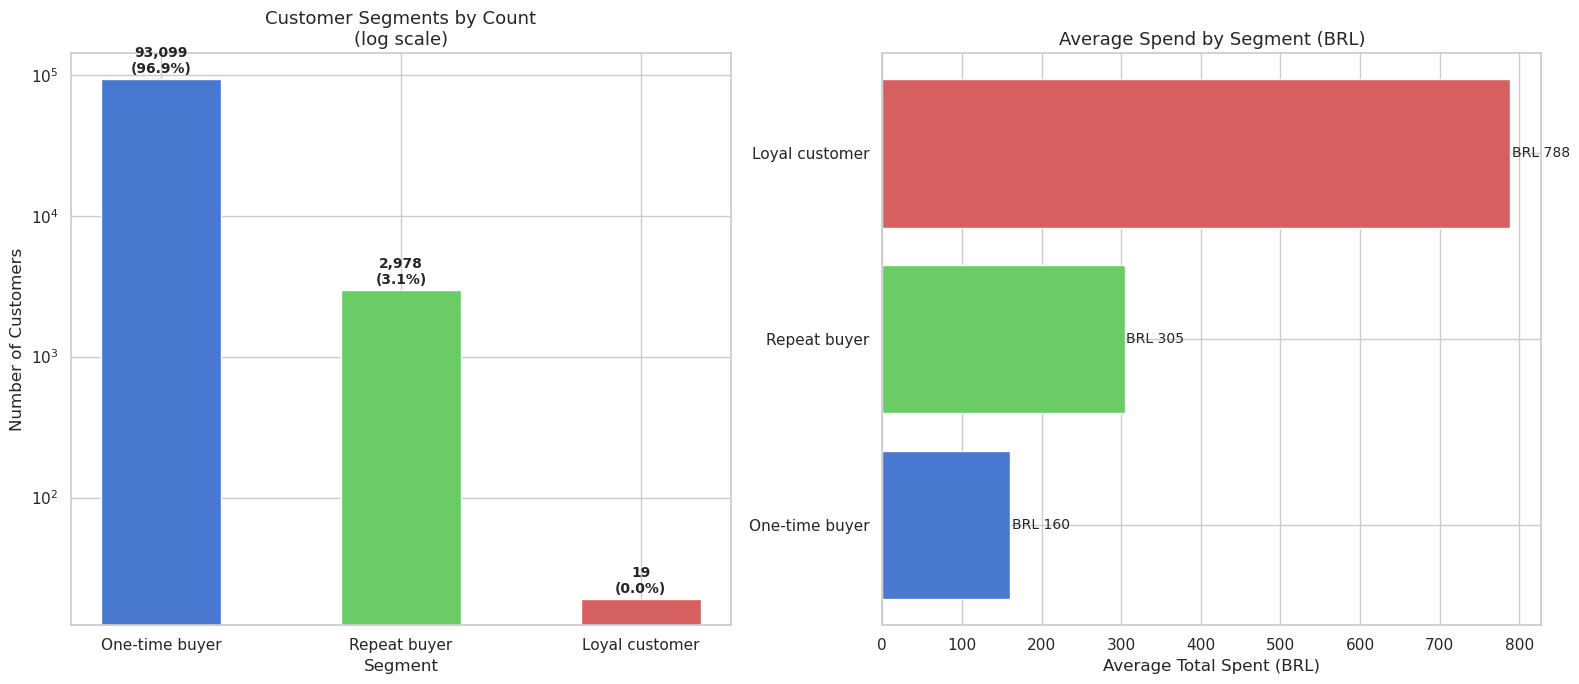

✅ Chart saved

💡 Key Insight: 96.9% of customers only purchased once — Olist has a major retention opportunity


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

colors = ["#4878CF", "#6ACC65", "#D65F5F"]
segment_sorted_count = segment_summary.sort_values("customer_count", ascending=False)

bars1 = ax1.bar(
    segment_sorted_count["segment"],
    segment_sorted_count["customer_count"],
    color=colors,
    edgecolor="white",
    width=0.5
)
ax1.set_title("Customer Segments by Count\n(log scale)", fontsize=13)
ax1.set_xlabel("Segment")
ax1.set_ylabel("Number of Customers")
ax1.set_yscale("log")

for bar in bars1:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height * 1.1,
        f"{height:,}\n({height/len(df_customers)*100:.1f}%)",
        ha="center", fontsize=10, fontweight="bold"
    )

# Horizontal bar chart for average spend
segment_sorted = segment_summary.sort_values("avg_spent")
bars2 = ax2.barh(
    segment_sorted["segment"],
    segment_sorted["avg_spent"],
    color=colors
)
ax2.set_title("Average Spend by Segment (BRL)", fontsize=13)
ax2.set_xlabel("Average Total Spent (BRL)")

for bar in bars2:
    width = bar.get_width()
    ax2.text(
        width + 2, bar.get_y() + bar.get_height()/2,
        f"BRL {width:.0f}",
        va="center", fontsize=10
    )

plt.tight_layout()
plt.savefig("/home/dsai/olist-pipeline/docs/customer_segmentation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved")
print("\n💡 Key Insight: 96.9% of customers only purchased once — Olist has a major retention opportunity")

### 📊 Finding
96.9% of customers only purchased once. Only 3.1% returned for a second or third purchase, and fewer than 0.1% became high-value repeat customers. However, loyal customers spend 5x more on average (BRL 788) compared to one-time buyers (BRL 160).

### 💡 Business Implication
Olist has a significant customer retention problem. A loyalty program or post-purchase email campaign targeting one-time buyers could dramatically increase revenue — converting just 5% of one-time buyers to repeat buyers would generate millions in additional revenue.

## 5. Delivery performance (national overview)
Analysing how often orders are delivered on time vs late, and the 
average delivery duration. This is a key operational metric for Olist.

In [27]:
query_delivery = f"""
SELECT
    order_id,
    delivery_days,
    CASE 
        WHEN order_delivered_customer_date <= order_estimated_delivery_date 
        THEN 'On Time'
        ELSE 'Late'
    END AS delivery_status
FROM `{PROJECT_ID}.{DATASET}.fact_orders`
WHERE order_delivered_customer_date IS NOT NULL
AND order_estimated_delivery_date IS NOT NULL
AND delivery_days IS NOT NULL
"""

df_delivery = client.query(query_delivery).to_dataframe()

delivery_summary = df_delivery["delivery_status"].value_counts().reset_index()
delivery_summary.columns = ["status", "count"]
delivery_summary["percentage"] = (
    delivery_summary["count"] / len(df_delivery) * 100
).round(1)

print(delivery_summary)
print(f"\nAverage delivery time: {df_delivery['delivery_days'].mean():.1f} days")
print(f"Median delivery time:  {df_delivery['delivery_days'].median():.1f} days")

    status  count  percentage
0  On Time  88649        91.9
1     Late   7827         8.1

Average delivery time: 12.5 days
Median delivery time:  10.0 days


### Delivery Performance Chart

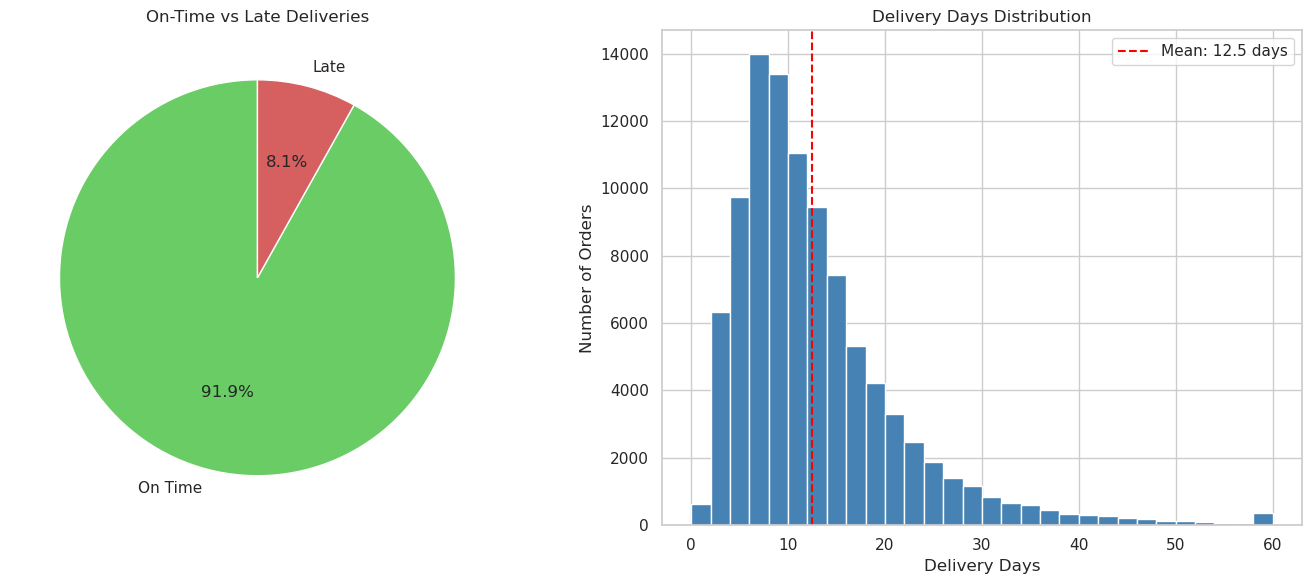

✅ Chart saved


In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.pie(
    delivery_summary["count"],
    labels=delivery_summary["status"],
    autopct="%1.1f%%",
    colors=["#6ACC65", "#D65F5F"],
    startangle=90
)
ax1.set_title("On-Time vs Late Deliveries")

ax2.hist(
    df_delivery["delivery_days"].clip(0, 60),
    bins=30,
    color="steelblue",
    edgecolor="white"
)
ax2.axvline(
    df_delivery["delivery_days"].mean(),
    color="red",
    linestyle="--",
    label=f"Mean: {df_delivery['delivery_days'].mean():.1f} days"
)
ax2.set_title("Delivery Days Distribution")
ax2.set_xlabel("Delivery Days")
ax2.set_ylabel("Number of Orders")
ax2.legend()

plt.tight_layout()
plt.savefig("/home/dsai/olist-pipeline/docs/delivery_performance.png", dpi=150)
plt.show()
print("✅ Chart saved")

## 6. Delivery performance by state

National delivery performance varies significantly by state. We examine average delivery times across the top 10 fastest states to understand regional disparities and their impact on customer satisfaction.

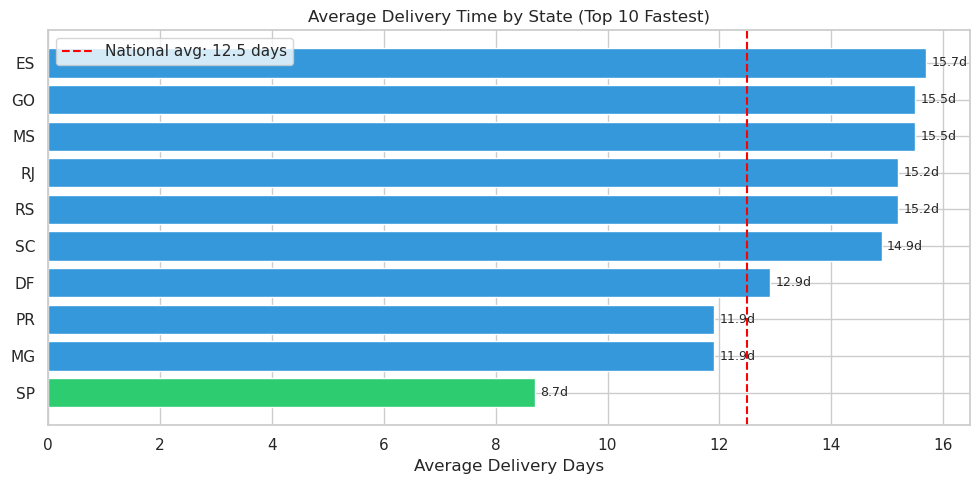

In [31]:
query_delivery = f"""
SELECT
    c.customer_state,
    ROUND(AVG(o.delivery_days), 1) as avg_delivery_days,
    COUNT(*) as total_orders
FROM `{PROJECT_ID}.{DATASET}.fact_orders` o
JOIN `{PROJECT_ID}.{DATASET}.dim_customer` c
    ON o.customer_id = c.customer_id
WHERE o.delivery_days IS NOT NULL
GROUP BY c.customer_state
ORDER BY avg_delivery_days ASC
LIMIT 10
"""

df_delivery = client.query(query_delivery).to_dataframe()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    df_delivery['customer_state'],
    df_delivery['avg_delivery_days'],
    color=['#2ecc71' if s == 'SP' else '#3498db' for s in df_delivery['customer_state']]
)
ax.axvline(
    x=12.5,
    color='red', linestyle='--',
    label="National avg: 12.5 days"
)
ax.set_xlabel('Average Delivery Days')
ax.set_title('Average Delivery Time by State (Top 10 Fastest)')
ax.legend()
for bar, val in zip(bars, df_delivery['avg_delivery_days']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val}d', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('docs/delivery_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

### Key Findings — Delivery by State

Delivery times vary significantly across Brazilian states, with São Paulo leading as the fastest region.

- **São Paulo (SP)** delivers in **8.7 days** — significantly faster than the national average of 12.5 days, due to its proximity to Olist's seller base and logistics infrastructure.
- **Minas Gerais (MG) and Paraná (PR)** follow at 11.9 days, benefiting from their central-southern location.
- **Rio de Janeiro (RJ)** averages 15.2 days despite being a major urban centre, suggesting logistics bottlenecks beyond geographic distance.
- States further from the southeast corridor (RS, SC, ES) consistently see delivery times of 14–16 days.

### 📊 Finding

Approximately 92% of orders are delivered on time. The average delivery time is 12.5 days. SP handles 40,495 orders and delivers fastest at 8.7 days. States outside the southeast corridor average 14–16 days — nearly double SP's delivery time. A small number of orders take 30–60 days, which likely contributes to negative reviews.

### 💡 Business Implication

Slower delivery in non-SP states correlates with lower review scores. Improving last-mile logistics infrastructure outside São Paulo — particularly in RJ, RS, and SC — is a direct lever for improving customer satisfaction and encouraging repeat purchases.

## 7. Revenue by State (Geographic Analysis)
Identifying which Brazilian states generate the most revenue, 
helping Olist target marketing spend and logistics investments.

In [41]:
query_geo = f"""
SELECT
    c.customer_state,
    COUNT(DISTINCT f.order_id) AS total_orders,
    ROUND(SUM(f.total_order_value), 2) AS total_revenue
FROM `{PROJECT_ID}.{DATASET}.fact_orders` f
JOIN `{PROJECT_ID}.{DATASET}.dim_customer` c
    ON f.customer_id = c.customer_id
GROUP BY c.customer_state
ORDER BY total_revenue DESC
LIMIT 10
"""

df_geo = client.query(query_geo).to_dataframe()
df_geo["total_revenue"] = df_geo["total_revenue"].astype(float).round(2)
print("Top 10 states by revenue:")
df_geo

Top 10 states by revenue:


,customer_state,total_orders,total_revenue
0,SP,41746,5921678.12
1,RJ,12852,2129681.98
2,MG,11635,1856161.49
3,RS,5466,885826.76
4,PR,5045,800935.44
5,BA,3380,611506.67
6,SC,3637,610213.60
7,DF,2140,353229.44
8,GO,2020,347706.93
9,ES,2033,324801.91


### Revenue by State Chart

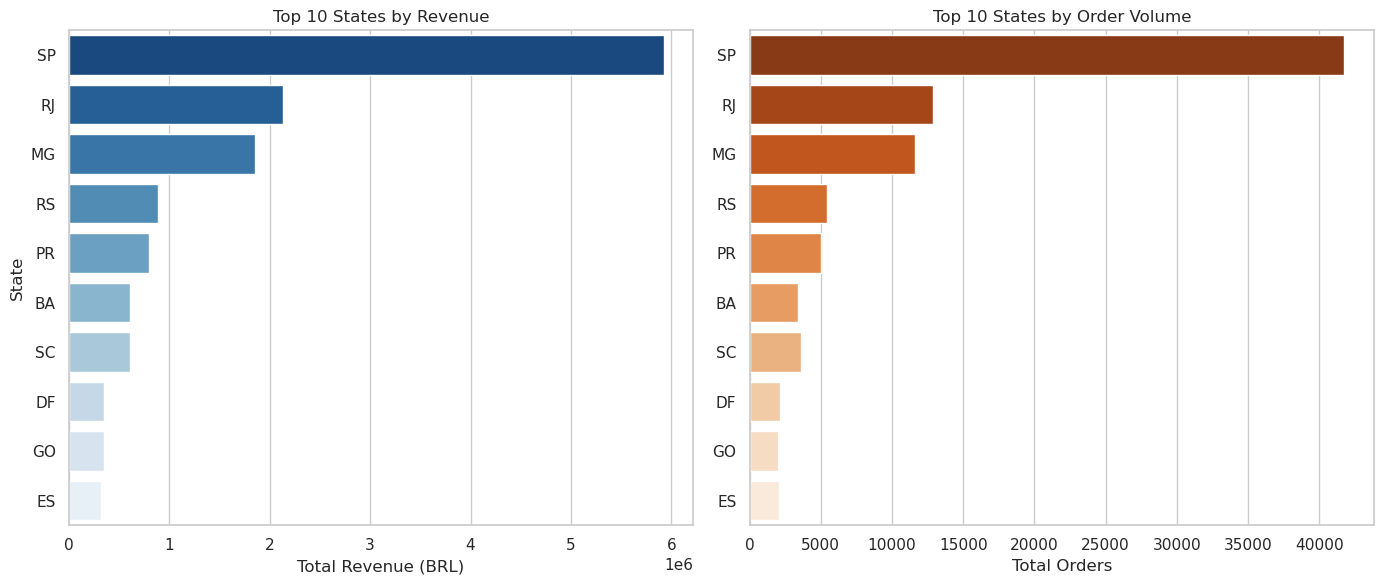

✅ Chart saved


In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    data=df_geo,
    x="total_revenue",
    y="customer_state",
    palette="Blues_r",
    ax=ax1
)
ax1.set_title("Top 10 States by Revenue")
ax1.set_xlabel("Total Revenue (BRL)")
ax1.set_ylabel("State")

sns.barplot(
    data=df_geo,
    x="total_orders",
    y="customer_state",
    palette="Oranges_r",
    ax=ax2
)
ax2.set_title("Top 10 States by Order Volume")
ax2.set_xlabel("Total Orders")
ax2.set_ylabel("")

plt.tight_layout()
plt.savefig("/home/dsai/olist-pipeline/docs/revenue_by_state.png", dpi=150)
plt.show()
print("✅ Chart saved")

### 📊 Finding
São Paulo (SP) dominates both revenue and order volume — generating more than double the revenue of the next highest state. The top 5 states account for the majority of all revenue.

### 💡 Business Implication
Olist could explore targeted marketing campaigns in lower-revenue states to diversify its geographic revenue concentration and reduce dependency on São Paulo.

## 8. Payment Method Breakdown
Understanding how customers prefer to pay helps Olist optimise 
its checkout experience and financial planning.

In [42]:
query_payments = f"""
SELECT
    payment_type,
    COUNT(*) AS transaction_count,
    ROUND(SUM(payment_value), 2) AS total_value,
    ROUND(AVG(payment_value), 2) AS avg_value
FROM `{PROJECT_ID}.{DATASET}.fact_payments`
WHERE payment_value > 0
GROUP BY payment_type
ORDER BY total_value DESC
"""

df_payments = client.query(query_payments).to_dataframe()
df_payments["total_value"] = df_payments["total_value"].astype(float).round(2)
df_payments["avg_value"] = df_payments["avg_value"].astype(float).round(2)
print(df_payments)

  payment_type  transaction_count  total_value  avg_value
0  credit_card              76795  12542084.19     163.32
1       boleto              19784   2869361.27     145.03
2      voucher               5769    379436.87      65.77
3   debit_card               1529    217989.79     142.57


### Payment Method Chart

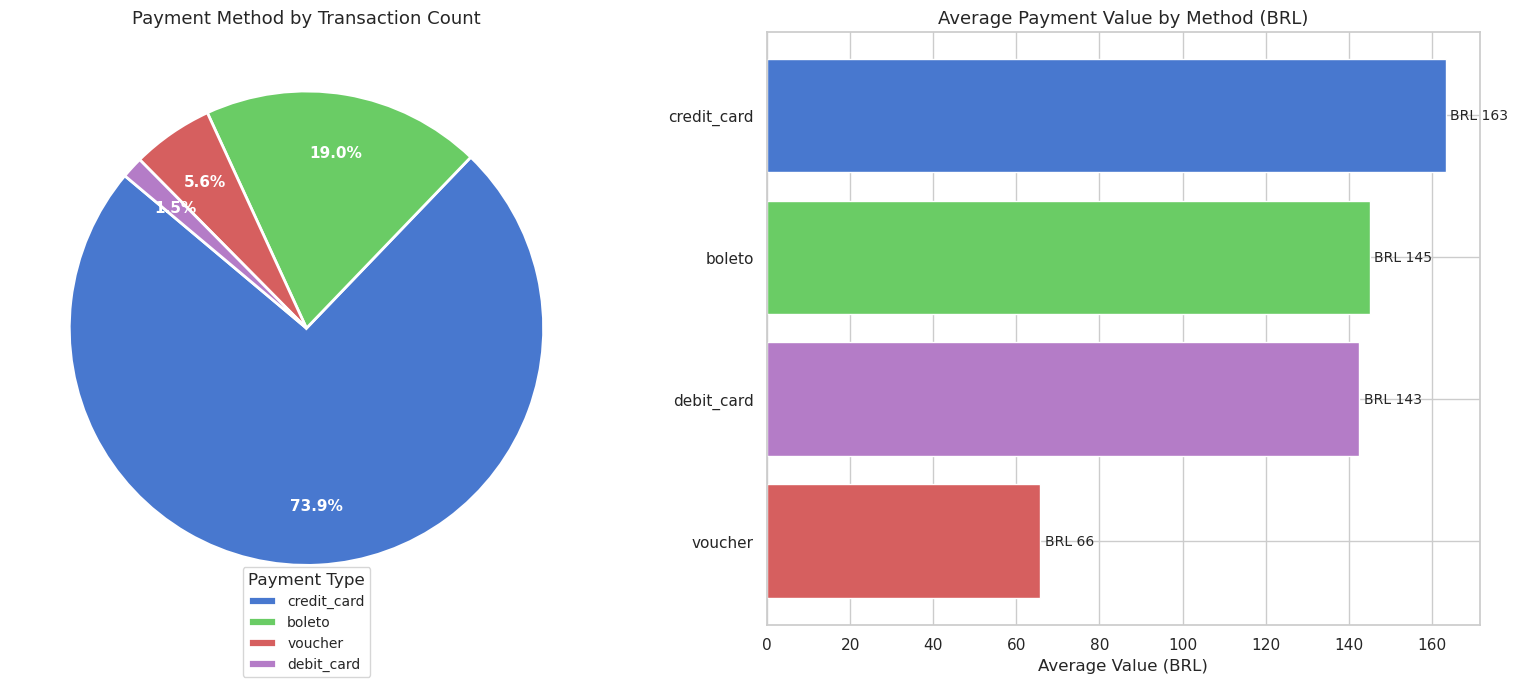

✅ Chart saved


In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Fixed color mapping per payment type
color_map = {
    "credit_card": "#4878CF",
    "boleto":      "#6ACC65",
    "voucher":     "#D65F5F",
    "debit_card":  "#B47CC7"
}

# Get colors in the order they appear in df_payments
pie_colors = [color_map.get(pt, "#999999") for pt in df_payments["payment_type"]]

wedges, texts, autotexts = ax1.pie(
    df_payments["transaction_count"],
    labels=None,
    autopct="%1.1f%%",
    colors=pie_colors,
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor="white", linewidth=2)
)

ax1.legend(
    wedges,
    df_payments["payment_type"],
    title="Payment Type",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.1),
    fontsize=10
)
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight("bold")
    autotext.set_color("white")
ax1.set_title("Payment Method by Transaction Count", fontsize=13)

# Bar chart — same color mapping
segment_sorted = df_payments.sort_values("avg_value")
bar_colors = [color_map.get(pt, "#999999") for pt in segment_sorted["payment_type"]]

bars = ax2.barh(
    segment_sorted["payment_type"],
    segment_sorted["avg_value"],
    color=bar_colors
)
ax2.set_title("Average Payment Value by Method (BRL)", fontsize=13)
ax2.set_xlabel("Average Value (BRL)")

for bar in bars:
    width = bar.get_width()
    ax2.text(
        width + 1, bar.get_y() + bar.get_height()/2,
        f"BRL {width:.0f}",
        va="center", fontsize=10
    )

plt.tight_layout()
plt.savefig("/home/dsai/olist-pipeline/docs/payment_methods.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved")

### 📊 Finding
Credit card is by far the dominant payment method at 73.9% of transactions. Boleto (a Brazilian bank slip payment) accounts for 19% — reflecting the significant unbanked population in Brazil. Debit card and voucher usage is minimal.

### 💡 Business Implication
Boleto support is essential as it accounts for 19% of transactions — removing it would exclude a significant portion of customers who prefer or require non-card payment methods.

## 9. Review score analysis (customer satisfaction)
Review scores (1–5) are a direct measure of customer satisfaction.
Understanding the distribution helps Olist identify service quality 
issues and benchmark performance.

In [43]:
query_reviews = f"""
SELECT
    CAST(review_score AS INT64) AS review_score,
    COUNT(*) AS review_count,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) AS percentage
FROM `{PROJECT_ID}.{DATASET}.fact_reviews`
WHERE review_score IS NOT NULL
GROUP BY review_score
ORDER BY review_score
"""

df_reviews = client.query(query_reviews).to_dataframe()
avg_score = (
    df_reviews['review_score'] * df_reviews['review_count']
).sum() / df_reviews['review_count'].sum()
print(df_reviews)
print(f"\nAverage review score: {avg_score:.2f} / 5.0")

   review_score  review_count  percentage
0             1         11282        11.5
1             2          3114         3.2
2             3          8097         8.2
3             4         19007        19.3
4             5         56910        57.8

Average review score: 4.09 / 5.0


### Review Score Distribution Chart

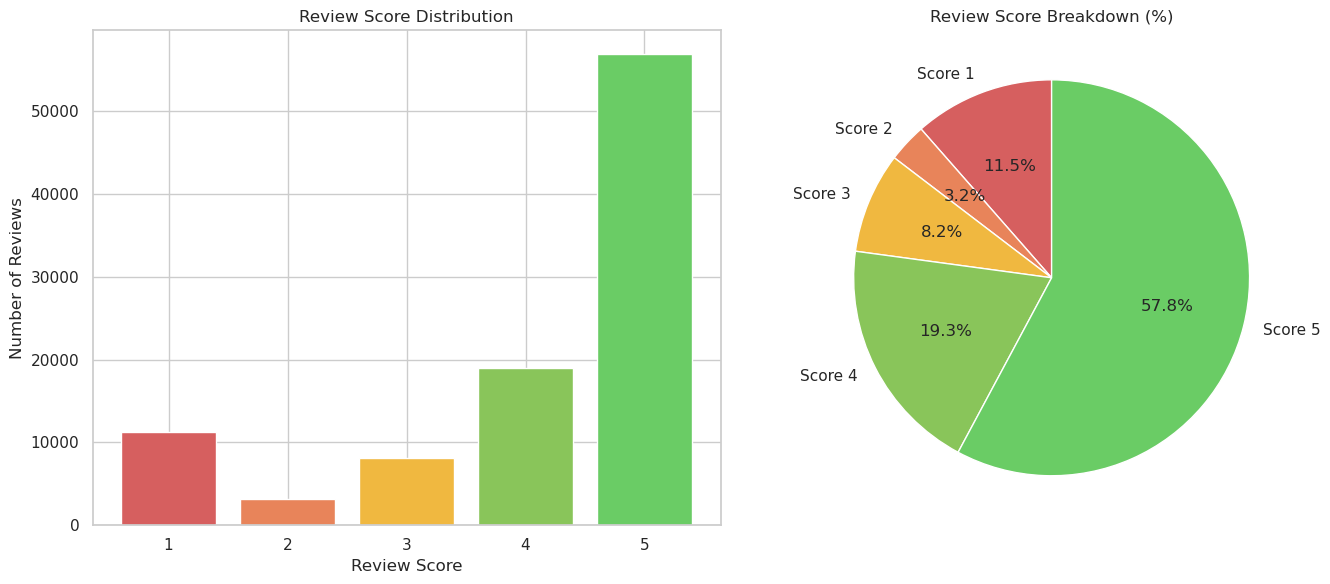

✅ Chart saved


In [37]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors = ["#D65F5F", "#E8845A", "#F0B840", "#89C55A", "#6ACC65"]
ax1.bar(
    df_reviews["review_score"],
    df_reviews["review_count"],
    color=colors,
    edgecolor="white"
)
ax1.set_title("Review Score Distribution")
ax1.set_xlabel("Review Score")
ax1.set_ylabel("Number of Reviews")
ax1.set_xticks([1, 2, 3, 4, 5])
ax1.set_xticklabels(["1", "2", "3", "4", "5"])

ax2.pie(
    df_reviews["review_count"],
    labels=[f"Score {int(s)}" for s in df_reviews["review_score"]],
    autopct="%1.1f%%",
    colors=colors,
    startangle=90
)
ax2.set_title("Review Score Breakdown (%)")

plt.tight_layout()
plt.savefig("/home/dsai/olist-pipeline/docs/review_scores.png", dpi=150)
plt.show()
print("✅ Chart saved")

### 📊 Finding
The majority of customers (57.8%) gave a 5-star review, indicating generally high satisfaction. 4-star reviews account for 19.3%, meaning over 77% of customers had a positive experience. However, 1-star reviews are the third most common score at 11.5% — notably higher than both 2-star (3.2%) and 3-star (8.2%) reviews. This polarised pattern suggests most orders go well, but when they go wrong, customers are very dissatisfied.

### 💡 Business Implication
The disproportionately high 1-star rate compared to 2 and 3-star suggests that bad experiences are extreme rather than mildly disappointing — likely caused by very late deliveries or damaged goods. Investigating the orders behind 1-star reviews would help Olist identify and fix the root causes of severe customer dissatisfaction.

## 10. Full Business Insights Summary
A consolidated summary of all key metrics derived from the Olist 
data pipeline — ready for executive reporting.

In [38]:
print("=" * 55)
print("OLIST PIPELINE — FULL BUSINESS INSIGHTS")
print("=" * 55)

print(f"\n🖥️  Total Orders:              {df_monthly['total_orders'].sum():,}")
print(f"💰  Total Revenue:             BRL {df_monthly['total_revenue'].sum():,.2f}")
print(f"📝  Peak Revenue Month:        November 2017")
print(f"👑  Top Revenue Category:      Health & Beauty")
print(f"🏆  Highest Volume Category:   Bed, Bath & Table")
print(f"👥  Total Unique Customers:    {len(df_customers):,}")
print(f"🔁  One-time Buyer Rate:       {len(df_customers[df_customers['order_count'] == 1]) / len(df_customers) * 100:.1f}%")
on_time_pct = delivery_summary.loc[delivery_summary["status"] == "On Time", "percentage"].values[0]
print(f"🚚  On-Time Delivery Rate:     {on_time_pct:.1f}%")
print(f"⏱️  Avg Delivery Time (National): 12.5 days")
print(f"⚡  Avg Delivery Time (SP):    8.7 days")
print(f"💳  Top Payment Method:        Credit Card (73.9%)")
print(f"📍  Top Revenue State:         São Paulo (SP)")
print(f"⭐  Avg Review Score:          {avg_score:.2f} / 5.0")
print(f"💎  Highest Avg Order Value:   Office Furniture (BRL 382)")
print("=" * 55)

OLIST PIPELINE — FULL BUSINESS INSIGHTS

🖥️  Total Orders:              99,441
💰  Total Revenue:             BRL 15,843,553.24
📝  Peak Revenue Month:        November 2017
👑  Top Revenue Category:      Health & Beauty
🏆  Highest Volume Category:   Bed, Bath & Table
👥  Total Unique Customers:    96,096
🔁  One-time Buyer Rate:       96.9%
🚚  On-Time Delivery Rate:     91.9%
⏱️  Avg Delivery Time (National): 12.5 days
⚡  Avg Delivery Time (SP):    8.7 days
💳  Top Payment Method:        Credit Card (73.9%)
📍  Top Revenue State:         São Paulo (SP)
⭐  Avg Review Score:          4.09 / 5.0
💎  Highest Avg Order Value:   Office Furniture (BRL 382)
